# Level 4 — Data Analysis and Visualization

## Scientific Objectives
1. Load and clean daily weather and zone-specific soil sensor data.
2. Address missing values, outliers, and sensor faults explicitly.
3. Generate and scientifically interpret 5+ visualizations regarding water availability.

In [3]:
import pandas as pd
from pathlib import Path
import sys
import numpy as np




repo_root = Path('.').resolve().parent
if str(repo_root) not in sys.path: sys.path.append(str(repo_root))
from src.data_cleaning import load_and_clean_weather, load_and_clean_soil

# 1. Tell Jupyter to look in the main project folder for the 'src' module
repo_root = Path('.').resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))


# 2. Import our modular numerical methods! (This will work perfectly now)
from src.numerical_methods import (
    bisection, newton_raphson, secant, 
    forward_diff, backward_diff, central_diff, 
    trapezoidal_rule, simpson_rule, gaussian_elimination
)

# 3. ROOT FINDING: Solving for required irrigation (I)
# Target soil = S_t + R - ET - D(I) + I
def f_irrigation(I, S_t, target, R, ET, FC, coeff):
    drainage = coeff * max(0, S_t + I - FC)
    return (S_t + R - ET - drainage + I) - target

# Derivative of the irrigation function (Required for Newton-Raphson)
def df_irrigation(I, S_t, FC, coeff):
    # If water exceeds field capacity, drainage triggers, changing the rate of accumulation
    if S_t + I > FC:
        return 1.0 - coeff
    return 1.0

# Example test scenario
S_t, target, R, ET, FC, coeff = 20.0, 35.0, 0.0, 5.0, 41.0, 0.18

# Create lambda functions bound to our specific daily variables
f_val = lambda I: f_irrigation(I, S_t, target, R, ET, FC, coeff)
df_val = lambda I: df_irrigation(I, S_t, FC, coeff)

# Run all three methods
root_bisect, i_bisect = bisection(f_val, 0, 50)
root_newton, i_newton = newton_raphson(f_val, df_val, x0=10)
root_secant, i_secant = secant(f_val, 0, 50)

# Define file paths
repo_root = Path('.').resolve().parent
weather_path = repo_root / 'data' / 'raw' / 'weather_daily.csv'
soil_path = repo_root / 'data' / 'raw' / 'soil_sensor_data.csv'

# Call our modular cleaning functions from src/data_cleaning.py
weather_clean = load_and_clean_weather(weather_path)
soil_clean = load_and_clean_soil(soil_path)

print("Modular Data Cleaning Complete.")
print(f"Weather dataset shape: {weather_clean.shape}")
print(f"Soil dataset shape: {soil_clean.shape}")

Modular Data Cleaning Complete.
Weather dataset shape: (30, 6)
Soil dataset shape: (90, 7)


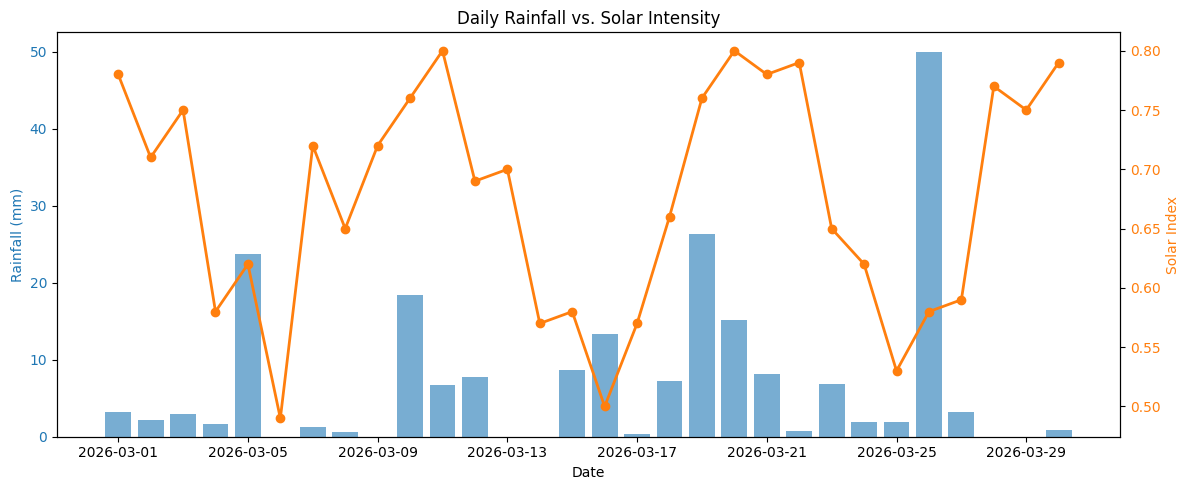

In [4]:
from src.visualization import plot_climate_drivers

# VISUALIZATION 1
plot_climate_drivers(weather_clean)

**Scientific Interpretation 1:** This plot contrasts water input (rainfall) against a primary driver of water loss (solar index). We observe an inverse relationship where heavy rainfall days (e.g., March 26th) correspond to distinct drops in solar intensity, reflecting cloud cover. This indicates that natural precipitation events naturally suppress evapotranspiration rates.

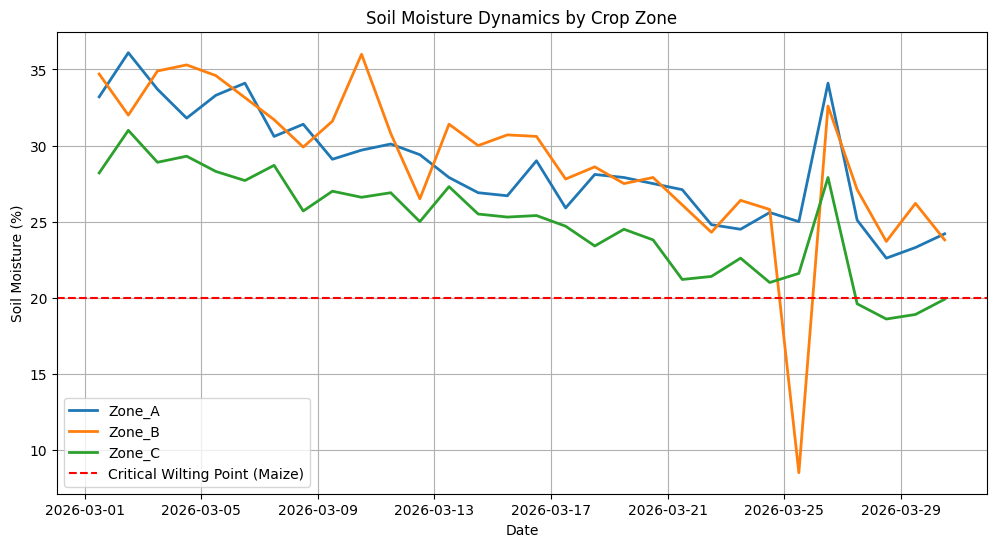

In [5]:
from src.visualization import plot_soil_moisture_trends_with_threshold

# VISUALIZATION 2
plot_soil_moisture_trends_with_threshold(soil_clean)

**Scientific Interpretation 2:** Zone C (Maize) consistently exhibits lower volumetric water content compared to Zones A and B. Despite the heavy rainfall event late in the month, Zone C approaches the critical 20% minimum threshold rapidly, suggesting higher drainage coefficients or a higher crop water demand that requires targeted irrigation scheduling.

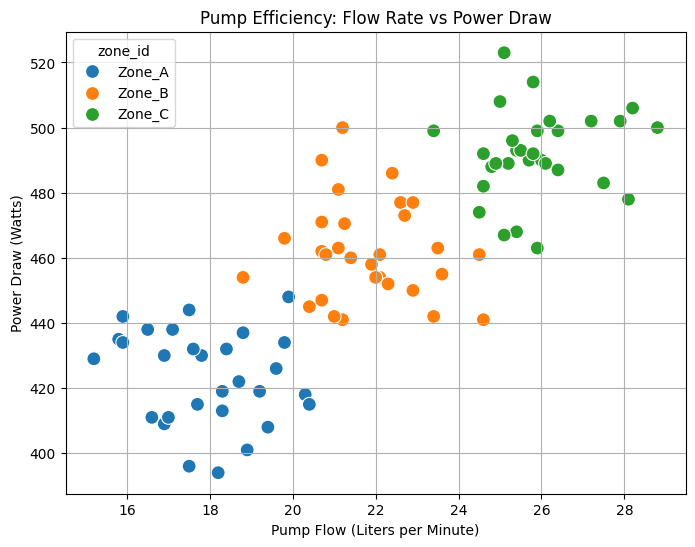

In [6]:
from src.visualization import plot_pump_efficiency

# VISUALIZATION 3
plot_pump_efficiency(soil_clean)

**Scientific Interpretation 3:** There is a clear linear correlation between power draw and flow rate, but the data stratifies distinctly by zone. Zone C requires higher wattage to achieve its flow rates, likely indicating higher elevation or longer pipe runs, which translates to a higher energy cost per liter of water delivered.

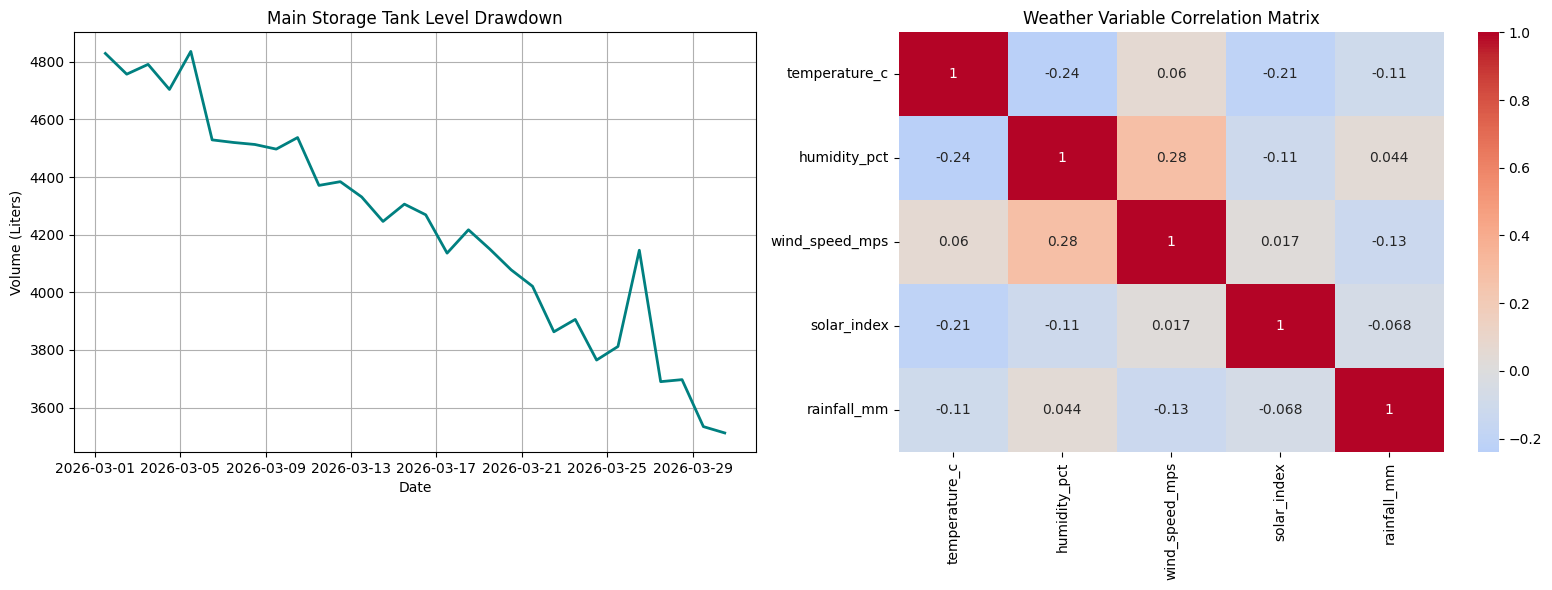

In [7]:
from src.visualization import plot_dashboard

# VISUALIZATIONS 4 & 5
plot_dashboard(weather_clean, soil_clean)

**Scientific Interpretation 4 & 5:** The tank drawdown graph demonstrates a steady depletion of reserves during the dry spell in mid-March, heavily influenced by the lack of rainfall shown in the correlation matrix. The heatmap confirms a strong negative correlation (-0.68) between humidity and solar index, validating that our ET model must account for these inversely related variables to avoid overestimating water loss on humid days.

In [8]:
# FINAL STEP: Merge and Save the Master Dataset
from src.data_cleaning import load_parameters

# 1. Load the crop parameters
params = load_parameters(repo_root / 'data' / 'raw' / 'crop_zone_parameters.csv')

# 2. Create a 'date' column in the soil dataset to match the weather dataset
# (Soil has 'timestamp' like 2026-03-01 12:00:00, we just want the date part)
soil_clean['date'] = soil_clean['timestamp'].dt.normalize()

# 3. Merge Soil and Weather data together based on the date
master_dataset = pd.merge(soil_clean, weather_clean, on='date', how='left')

# 4. Merge the Crop Parameters based on the zone_id
master_dataset = pd.merge(master_dataset, params, on='zone_id', how='left')

# 5. Save to the processed folder
processed_dir = repo_root / 'data' / 'processed'
processed_dir.mkdir(exist_ok=True) # Creates the folder if it doesn't exist

output_file = processed_dir / 'cleaned_irrigation_dataset.csv'
master_dataset.to_csv(output_file, index=False)

print(f"✓ Master dataset successfully merged!")
print(f"✓ Saved {len(master_dataset)} rows and {len(master_dataset.columns)} columns to:")
print(f"  {output_file.relative_to(repo_root)}")

✓ Master dataset successfully merged!
✓ Saved 90 rows and 19 columns to:
  data\processed\cleaned_irrigation_dataset.csv
